In [14]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [15]:
import os
print(os.getcwd())
print(os.listdir())

d:\users\OneDrive\Documents\Desktop\CreditCardProject\5) Project Development Phase
['app.py', 'best_creditcard_model.pkl', 'internship_project.ipynb', 'Procfile', 'requirements.txt', 'static', 'templates']


In [16]:
credict = pd.read_csv(r"..\4) Project Planning Phase\creditcard.csv")

In [17]:
credict.head()#gives first five rows of our dataser
credict.shape
credict.size

8829017

In [18]:
# To get all stastical information from dataset
credict.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [19]:
# To get all information
# credict.info()

In [20]:
# To know the all columns in dataset
# credict.columns

In [21]:
# Checking missing values
# credict.isnull().sum()

Class
0    284315
1       492
Name: count, dtype: int64


<Axes: xlabel='Class'>

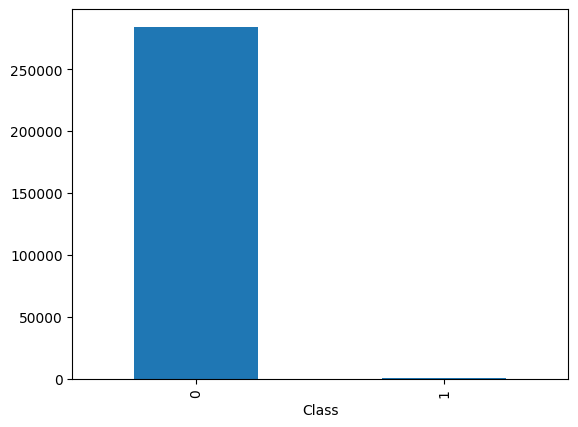

In [22]:
# Univariate Analysis
print(credict["Class"].value_counts())
credict['Class'].value_counts().plot(kind='bar')

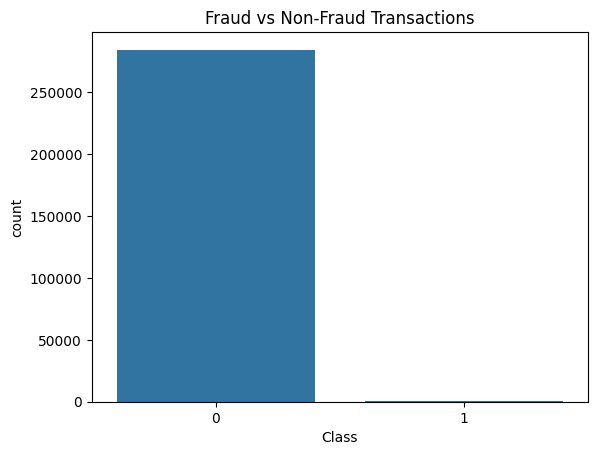

In [23]:
sns.countplot(x="Class", data=credict)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

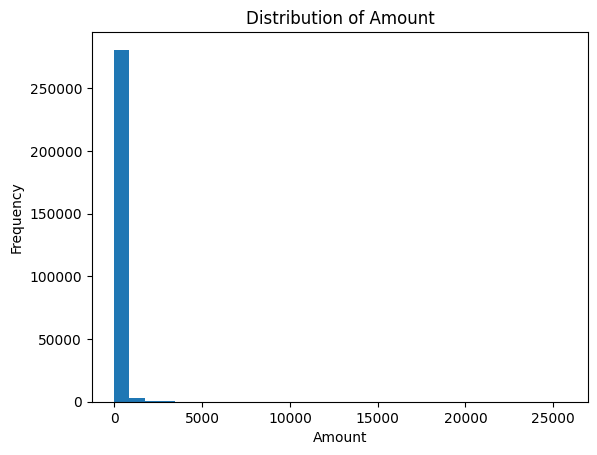

In [24]:
#Histogram of Amount
plt.hist(credict["Amount"], bins=30)
plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

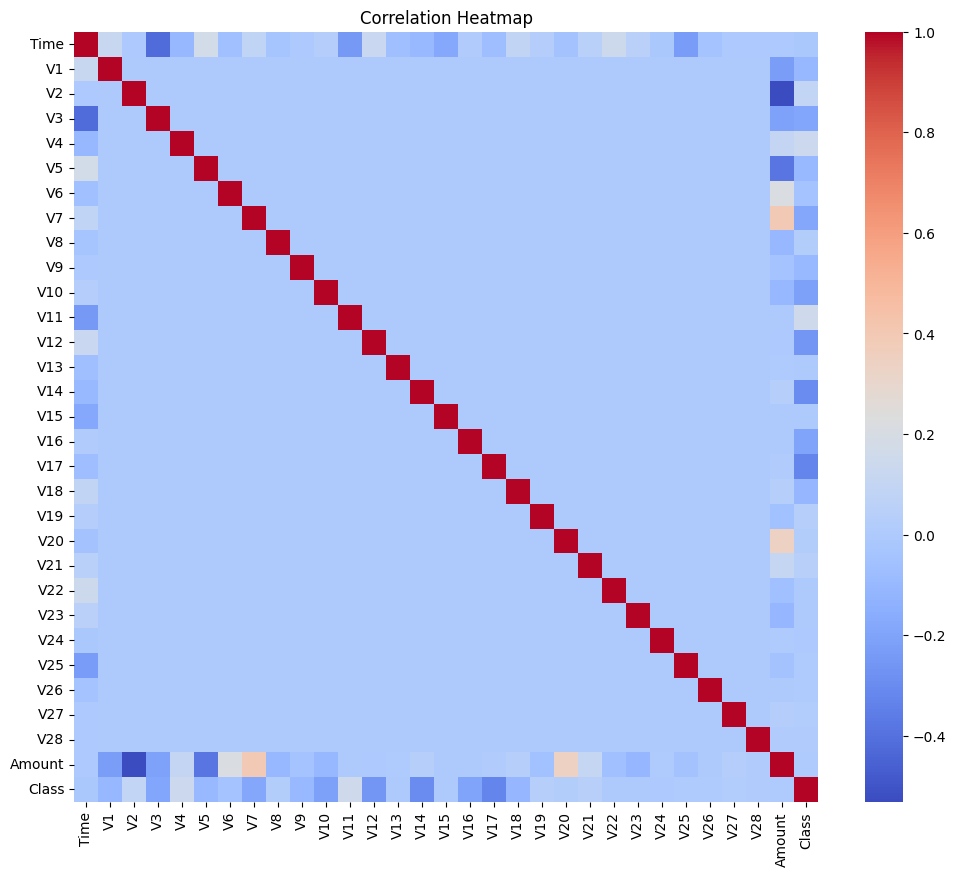

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(credict.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# # Pair plot
# sample = credict[['Time', 'Amount', 'V1', 'V2', 'Class']]

# sns.pairplot(sample, hue='Class')
# plt.show()

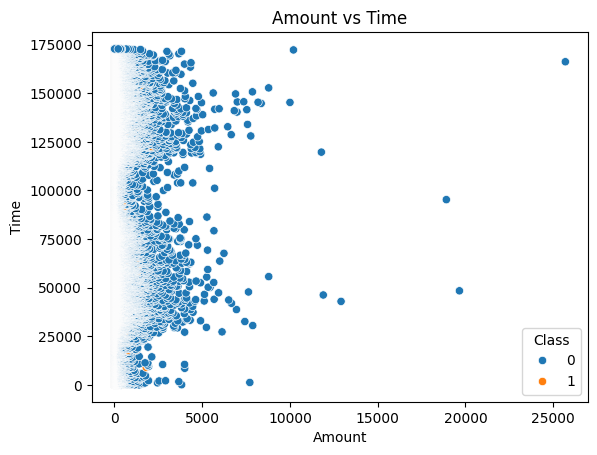

In [27]:
sns.scatterplot(data=credict, x='Amount', y='Time', hue='Class')
plt.title("Amount vs Time")
plt.show()

In [28]:





# Descriptive Analysis
credict.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
credict.size

8829017

In [30]:
credict.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [31]:
credict.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [32]:
credict.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [33]:
credict=credict.dropna()

In [34]:
print(credict['Amount'].mean())

88.34961925093134


In [35]:
print(credict['Amount'].median())

22.0


In [36]:
print(credict['Amount'].std())

250.12010924018855


In [37]:
#Droping duplicates
credict=credict.drop_duplicates()

In [38]:
# Handling missing values
credict

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [39]:
credict['Amount']=credict['Amount'].fillna(credict['Amount'].mean())

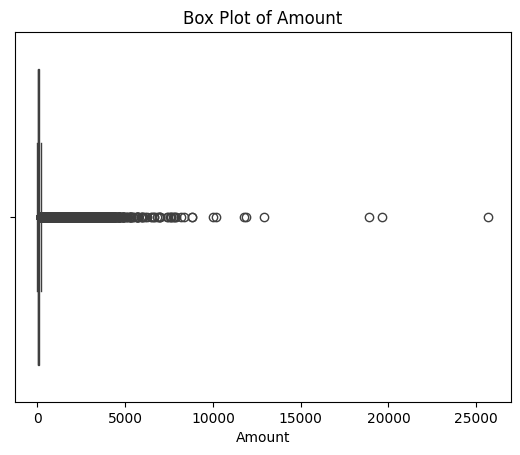

In [40]:
# Cleaning dataset
sns.boxplot(x=credict["Amount"])
plt.title("Box Plot of Amount")
plt.show()

In [41]:
# Feature engineering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

credict['Amount'] = scaler.fit_transform(credict[['Amount']])

In [42]:
credict['Time'] = scaler.fit_transform(credict[['Time']])

In [43]:
x= credict.drop('Class', axis=1)
y = credict['Class']
x.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
dtype: int64

In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_test.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
dtype: int64

In [45]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
logisticmodel=LogisticRegression(max_iter=1000)
logisticmodel.fit(x_train,y_train)
y_pred=logisticmodel.predict(x_test)

In [46]:
# Model evualation
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
accuracy=accuracy_score(y_test,y_pred)
cr=classification_report(y_test,y_pred)
confusion_metrix=confusion_matrix(y_test,y_pred)

In [47]:
print("Accuracy",accuracy)
print("classification_report",cr)
print("Confusion_metrix\n",confusion_metrix)

Accuracy 0.9991541254009093
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.53      0.67        90

    accuracy                           1.00     56746
   macro avg       0.94      0.77      0.83     56746
weighted avg       1.00      1.00      1.00     56746

Confusion_metrix
 [[56650     6]
 [   42    48]]


In [48]:
from sklearn.ensemble import RandomForestClassifier

randommodel = RandomForestClassifier(
    n_estimators=20,
    random_state=42
)

randommodel.fit(x_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
yr_pred=randommodel.predict(x_test)

In [50]:
accuracy=accuracy_score(y_test,yr_pred)
confusion_metrix=confusion_matrix(y_test,yr_pred)
cr=classification_report(y_test,yr_pred)


In [51]:
print("Accuracy",accuracy)
print("classification_report",cr)
print("Confusion_metrix\n",confusion_metrix)

Accuracy 0.9995594403129736
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.99      0.73      0.84        90

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion_metrix
 [[56655     1]
 [   24    66]]


In [52]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier
treemodel=DecisionTreeClassifier(random_state=42)
treemodel.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [53]:
yt_pred=treemodel.predict(x_test)
cr=classification_report(y_test,yt_pred)
confusion_metrix=confusion_matrix(y_test,yt_pred)

In [54]:
print("Accuracy",accuracy)
print("classification_report",cr)

print("Confusion_metrix\n",confusion_metrix)

Accuracy 0.9995594403129736
classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.67      0.71      0.69        90

    accuracy                           1.00     56746
   macro avg       0.83      0.86      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Confusion_metrix
 [[56624    32]
 [   26    64]]


In [55]:
from xgboost import XGBClassifier

xgbmodel = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgbmodel.fit(x_train, y_train)

yx_pred = xgbmodel.predict(x_test)

accuracy = accuracy_score(y_test, yx_pred)
cr = classification_report(y_test, yx_pred)
confusion_matrix1 = confusion_matrix(y_test, yx_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", cr)
print("Confusion Matrix:\n", confusion_matrix1)

Accuracy: 0.9951890882176717
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.04      0.10      0.06        90

    accuracy                           1.00     56746
   macro avg       0.52      0.55      0.53     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
 [[56464   192]
 [   81     9]]


In [56]:
models = {
    "Logistic Regression": logisticmodel,
    "Random Forest": randommodel,
    "Decision Tree": treemodel,
    "XGBoost": xgbmodel
}

accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, yr_pred),
    "Decision Tree": accuracy_score(y_test, yt_pred),
    "XGBoost": accuracy_score(y_test, yx_pred)
}

In [57]:
best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Accuracy:", accuracies[best_model_name])

Best Model: Random Forest
Accuracy: 0.9995594403129736


In [58]:
import joblib

joblib.dump(best_model, "best_creditcard_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [59]:
loaded_model = joblib.load("best_creditcard_model.pkl")

In [61]:
# from google.colab import files
# files.download("best_creditcard_model.pkl")